# Cell Embedding Analysis Notebook
This notebook performs clustering and visualization of single-cell data using pre-computed embeddings. The workflow includes:
1. Loading dataset and embeddings
2. Preprocessing data
3. Performing unsupervised clustering
4. Generating UMAP visualizations
5. Calculating scIB metrics (commented out by default)

This notebook uses __*xTrimoGene*__ as an example.

## 1. Configuration Setup
Replace these values with your actual paths and parameters

In [13]:
DEVICE = 'cuda'                # Use 'cuda' for GPU or 'cpu'
DATA_FOLDER = '/mnt/nvme/extra_data/wujialu/scFM-Bench/data/datasets'  # Folder containing datasets
DATASET_NAME = 'pancreas_scib'   # Name of dataset to analyze
BATCH_COL = 'batch'              # Column name for batch information
LABEL_COL = 'celltype'           # Column name for cell type labels
LAYER_KEY = 'counts'             # Key for raw counts layer ('X' for main matrix)
MODEL_NAME = 'xTrimoGene'               # Model name: 'HVG', 'scVI', or custom model
OUTPUT_FOLDER = '/mnt/nvme/extra_data/wujialu/scFM-Bench/output'       # Output directory for results
EMBEDDING_FILE = "cell_emb.npy"  # Precomputed embedding filename

## 2. Import Dependencies

In [14]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
import warnings

# Set environment to suppress warnings
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings("ignore")

## 3. Derived Configuration
Automatically generated based on global parameters

In [15]:
# ===== DERIVED CONFIGURATION =====
# Set file paths and keys
ADATA_PATH = os.path.join(DATA_FOLDER, f"{DATASET_NAME}.h5ad")
EMBEDDING_KEY = f"X_{MODEL_NAME.lower()}"
OUTPUT_DIR = os.path.join(OUTPUT_FOLDER, DATASET_NAME, LAYER_KEY, MODEL_NAME)

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model-specific file names
if MODEL_NAME.lower() == "xtrimogene":
    EMBEDDING_FILE = "mapping_01B-resolution_singlecell_cell_embedding_t4.5_resolution.npy"
elif MODEL_NAME.lower() == "scvi":
    EMBEDDING_FILE = f"cell_emb_{BATCH_COL}.npy"

EMBEDDING_PATH = os.path.join(OUTPUT_DIR, EMBEDDING_FILE)

## 4. Load Dataset
Load the AnnData object containing single-cell data

In [16]:
# Load dataset
adata = sc.read(ADATA_PATH)
print(f"Dataset loaded: {adata.shape[0]} cells, {adata.shape[1]} genes")

Dataset loaded: 16382 cells, 19093 genes


## 5. Data Preprocessing
Prepare data for analysis

In [17]:
# Access raw counts data
if LAYER_KEY == "X":
    if adata.raw is not None:
        adata.X = adata.raw.X.copy()
        print("Copied raw counts from adata.raw.X")
    else:
        print("Using existing adata.X matrix")
else:
    adata.X = adata.layers[LAYER_KEY].copy()
    print(f"Copied raw counts from layer: {LAYER_KEY}")

# Basic filtering
sc.pp.filter_cells(adata, min_genes=25)
sc.pp.filter_genes(adata, min_cells=10)
print(f"Filtered dataset shape: {adata.shape}")

Copied raw counts from layer: counts
Filtered dataset shape: (16382, 17379)


## 6. Load/Create Cell Embeddings
Depending on the model specified, either compute or load embeddings

In [18]:
if MODEL_NAME == "HVG":
    # Compute HVG embeddings
    print("Computing HVG embeddings...")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(
        adata, 
        flavor='seurat', 
        n_top_genes=2000, 
        batch_key=BATCH_COL
    )
    
    # Store HVG matrix as embedding
    adata.obsm[EMBEDDING_KEY] = adata.X[:, adata.var.highly_variable]
    
    # Convert to dense array if sparse
    if sparse.issparse(adata.obsm[EMBEDDING_KEY]):
        adata.obsm[EMBEDDING_KEY] = adata.obsm[EMBEDDING_KEY].toarray()
    
    print(f"Created HVG embeddings with {adata.obsm[EMBEDDING_KEY].shape[1]} features")

else:
    # Load precomputed embeddings
    print(f"Loading embeddings from: {EMBEDDING_PATH}")
    embeddings = np.load(EMBEDDING_PATH)
    adata.obsm[EMBEDDING_KEY] = embeddings
    print(f"Loaded embeddings with shape: {embeddings.shape}")


Loading embeddings from: /mnt/nvme/extra_data/wujialu/scFM-Bench/output/pancreas_scib/counts/xTrimoGene/mapping_01B-resolution_singlecell_cell_embedding_t4.5_resolution.npy
Loaded embeddings with shape: (16382, 3072)


## 7. UMAP Visualization
Generate and visualize UMAP projections

In [19]:
# Compute or load UMAP coordinates
UMAP_FILE = os.path.join(OUTPUT_DIR, "X_umap.npy")
if os.path.exists(UMAP_FILE):
    print("Loading precomputed UMAP coordinates")
    adata.obsm["X_umap"] = np.load(UMAP_FILE)
else:
    print("Computing UMAP from embeddings...")
    sc.pp.neighbors(adata, use_rep=EMBEDDING_KEY)
    sc.tl.umap(adata, min_dist=0.3)
    np.save(UMAP_FILE, adata.obsm["X_umap"])
    print(f"Saved UMAP coordinates to: {UMAP_FILE}")


Loading precomputed UMAP coordinates


### 7.1 UMAP by Cell Type
Visualize cell type clusters

<Figure size 480x400 with 0 Axes>

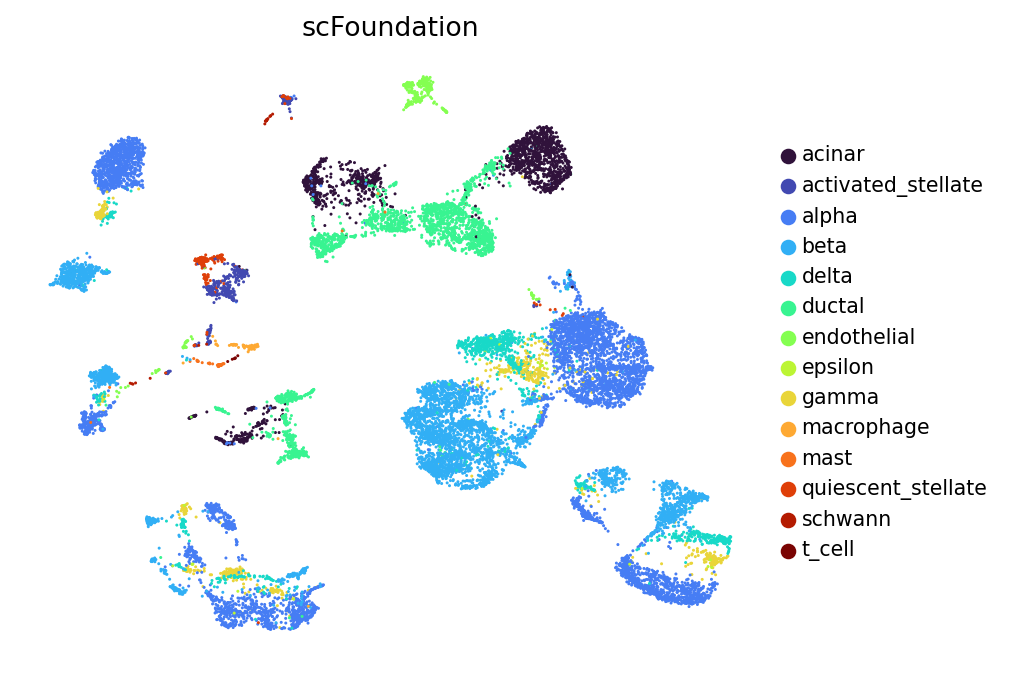

Saved cell type UMAP to: /mnt/nvme/extra_data/wujialu/scFM-Bench/output/pancreas_scib/counts/xTrimoGene/clustering_umap_celltype.png


In [20]:
# Set visualization parameters
sc.set_figure_params(
    facecolor="white",
    figsize=(6, 5),
    transparent=True,
    frameon=False,
    fontsize=10
)

# Plot cell type UMAP
num_categories = adata.obs[LABEL_COL].nunique()
plt.figure(figsize=(6, 5))
ax = sc.pl.umap(
    adata,
    color=LABEL_COL,
    show=False,
    legend_loc='right margin' if num_categories <= 20 else None,
    palette='turbo'
)

# Set title
title = "scFoundation" if MODEL_NAME == "xTrimoGene" else MODEL_NAME
ax.set_title(title, fontsize=12)

# Save plot
CELLTYPE_PATH = os.path.join(OUTPUT_DIR, "clustering_umap_celltype.png")
plt.savefig(CELLTYPE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved cell type UMAP to: {CELLTYPE_PATH}")

### 7.2 UMAP by Batch
Visualize batch effects

<Figure size 480x400 with 0 Axes>

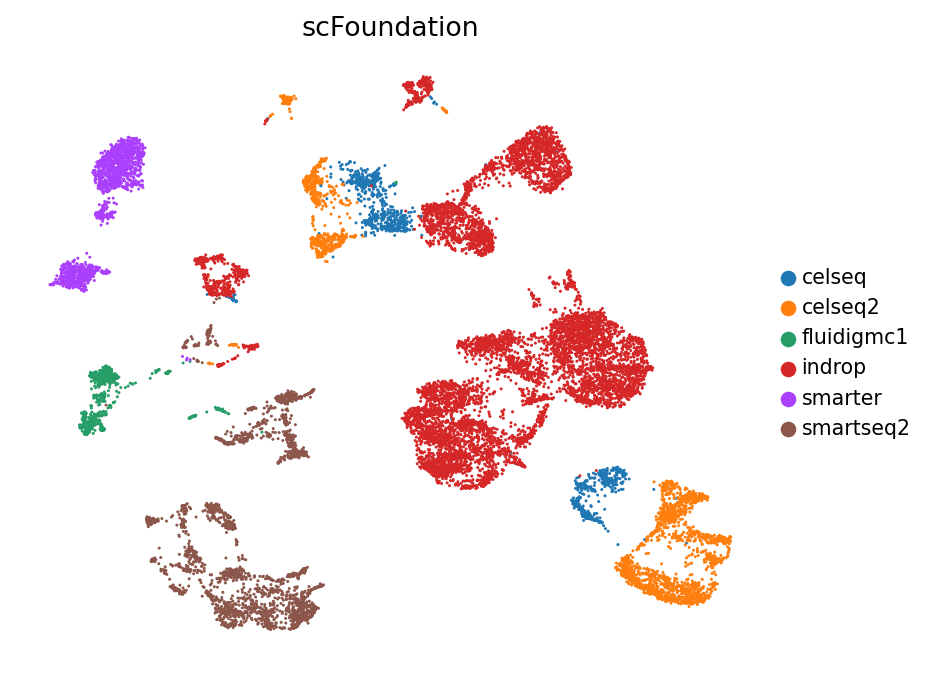

Saved batch UMAP to: /mnt/nvme/extra_data/wujialu/scFM-Bench/output/pancreas_scib/counts/xTrimoGene/clustering_umap_batch.png


In [21]:
# Plot batch UMAP
plt.figure(figsize=(6, 5))
ax = sc.pl.umap(adata, color=BATCH_COL, show=False)

# Set title
title = "scFoundation" if MODEL_NAME == "xTrimoGene" else MODEL_NAME
ax.set_title(title, fontsize=12)

# Save plot
BATCH_PATH = os.path.join(OUTPUT_DIR, "clustering_umap_batch.png")
plt.savefig(BATCH_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved batch UMAP to: {BATCH_PATH}")

In [22]:
print("\n" + "="*50)
print(f"Analysis complete for model: {MODEL_NAME}")
print(f"Results saved to: {OUTPUT_DIR}")
print("="*50)


Analysis complete for model: xTrimoGene
Results saved to: /mnt/nvme/extra_data/wujialu/scFM-Bench/output/pancreas_scib/counts/xTrimoGene
